In [ ]:
from utils import get_svamp_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3

import pandas as pd
import numpy as np

df = get_svamp_df()
order_numbers = [
    "smollm2:135m",
    "gemma3:270m",
    "smollm2:360m",
    "qwen2.5:0.5b",
    "qwen3:0.6b",
    "llama3.2:1b",
    "gemma3:1b",
    "qwen2-math:1.5b",
    "deepseek-r1:1.5b",
    "qwen3:1.7b",
    "smollm2:1.7b",
    "gemma-3-27b-it",
]

model_group = {
    "smollm2:135m": "Small",
    "gemma3:270m": "Small",
    "smollm2:360m": "Small",
    "qwen2.5:0.5b": "Medium",
    "qwen3:0.6b": "Medium",
    "llama3.2:1b": "Medium",
    "gemma3:1b": "Medium",
    "qwen2-math:1.5b": "Large (specialized)",
    "deepseek-r1:1.5b": "Large",
    "qwen3:1.7b": "Large",
    "smollm2:1.7b": "Large",
    "gemma-3-27b-it": "Extra Large",
}
models_info = {
    "smollm2:135m": (271, "Q4_K_M", 135000000),
    "gemma3:270m": (292, "Q8_0", 270000000),
    "smollm2:360m": (726, "Fp16", 360000000),
    "qwen2.5:0.5b": (398, "Q4_K_M", 500000000),
    "qwen3:0.6b": (523, "Q4_K_M", 600000000),
    "llama3.2:1b": (1300, "Q8_0", 1000000000),   # 1,3GB → 1300MB
    "gemma3:1b": (815, "Q4_K_M", 1000000000),
    "qwen2-math:1.5b": (935, "Q4_0", 1500000000),
    "deepseek-r1:1.5b": (1100, "Q4_K_M", 1500000000),
    "qwen3:1.7b": (1400, "Q4_K_M", 1700000000),
    "smollm2:1.7b": (1800, "Q8_0", 1700000000),
    "gemma-3-27b-it": (None, None, 17000000000),  # 17GB → 17000MB
}



df["model_rank"] = df["Model"].apply(lambda x: order_numbers.index(x))
df = df.sort_values(by="model_rank")
df["model_size"] = df["Model"].apply(lambda x: models_info[x][0])
df["quantization"] = df["Model"].apply(lambda x: models_info[x][1])

DP
DP-Reflection
ReAct
ReWOO


# Misclassified

In [ ]:
df_misc = get_svamp_df(include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.pivot_table(index="Model", columns="Method", values="ID", aggfunc="size", fill_value=0)

DP
DP-Reflection
ReAct
ReWOO


Method,Direktes Prompting,ReAct,ReWOO
Model,,,
deepseek-r1:1.5b,11,0,7
gemma-3-27b-it,4,0,0
gemma3:1b,1,0,8
llama3.2:1b,9,14,0
qwen2-math:1.5b,5,0,0
qwen2.5:0.5b,8,9,6
qwen3:0.6b,0,10,2
qwen3:1.7b,3,4,0
smollm2:360m,3,0,3


In [4]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 111
Total examples: 7668
Overall misclassification rate: 1.45%


In [7]:
df_misc.groupby(["Model", "Method", "Error Class"]).agg({
    "ID": "count",
}).reset_index().pivot_table(index=["Model"], columns="Method", values="ID", fill_value=pd.NA)

Method,Direktes Prompting,ReAct,ReWOO
Model,,,
deepseek-r1_1.5b,11.0,NaN,7.0
gemma-3-27b-it,4.0,NaN,NaN
gemma3_1b,1.0,NaN,8.0
llama3.2_1b,9.0,14.0,NaN
qwen2-math_1.5b,5.0,NaN,NaN
qwen2.5_0.5b,8.0,9.0,6.0
qwen3_0.6b,NaN,10.0,2.0
qwen3_1.7b,3.0,4.0,NaN
smollm2_1.7b,4.0,NaN,NaN


# Accuracy

## Overview

In [2]:
df_acc = df.groupby(["Method", "Model"]).agg({
    "is_correct": "mean",
}).reset_index()
# pivot to have Method as Columns
df_acc = df_acc.pivot_table(index=["Model"], columns="Method", values="is_correct", fill_value=np.nan).reset_index()

# reorder columns: Direktes Prompting, ReAct, ReWOO, DP-Reflection
df_acc = df_acc[["Model", "Direktes Prompting", "ReAct", "ReWOO", "DP-Reflection"]]
for m in ["Direktes Prompting", "ReAct", "ReWOO", "DP-Reflection"]:
    df_acc[m] = df_acc[m] * 100

df_acc["model_rank"] = df_acc["Model"].apply(lambda x: order_numbers.index(x))
df_acc = df_acc.sort_values(by="model_rank").drop(columns=["model_rank"])
df_acc.to_excel("SVAMP.xlsx", index=False)
df_acc.head(50)

C:\Users\patri\AppData\Local\Temp\ipykernel_23996\87278871.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_acc = df_acc.pivot_table(index=["Model"], columns="Method", values="is_correct", fill_value=np.nan).reset_index()


Method,Model,Direktes Prompting,ReAct,ReWOO,DP-Reflection
10,smollm2:135m,3.873239,NaN,1.056338,NaN
3,gemma3:270m,26.408451,NaN,7.746479,NaN
11,smollm2:360m,24.647887,NaN,15.140845,NaN
6,qwen2.5:0.5b,56.690141,33.802817,28.521127,48.591549
7,qwen3:0.6b,75.704225,84.154930,59.507042,84.859155
4,llama3.2:1b,68.309859,38.028169,23.239437,NaN
2,gemma3:1b,69.366197,NaN,27.464789,NaN
5,qwen2-math:1.5b,93.661972,NaN,1.056338,NaN
0,deepseek-r1:1.5b,83.450704,NaN,86.619718,78.169014
8,qwen3:1.7b,82.394366,96.126761,93.309859,94.014085


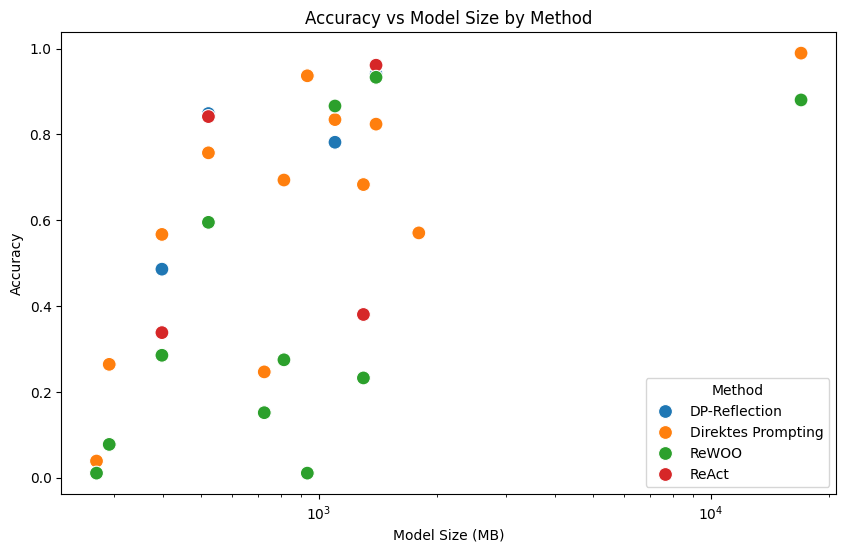

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_acc =  df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()

df_acc["model_size"] = df_acc["Model"].apply(lambda x: models_info[x][0])
df_acc["quantization"] = df_acc["Model"].apply(lambda x: models_info[x][1])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_acc,
    x="model_size",
    y="is_correct",
    hue="Method",
    palette="tab10",
    s=100
)
plt.xlabel("Model Size (MB)")
plt.xscale("log")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size by Method")
plt.show()

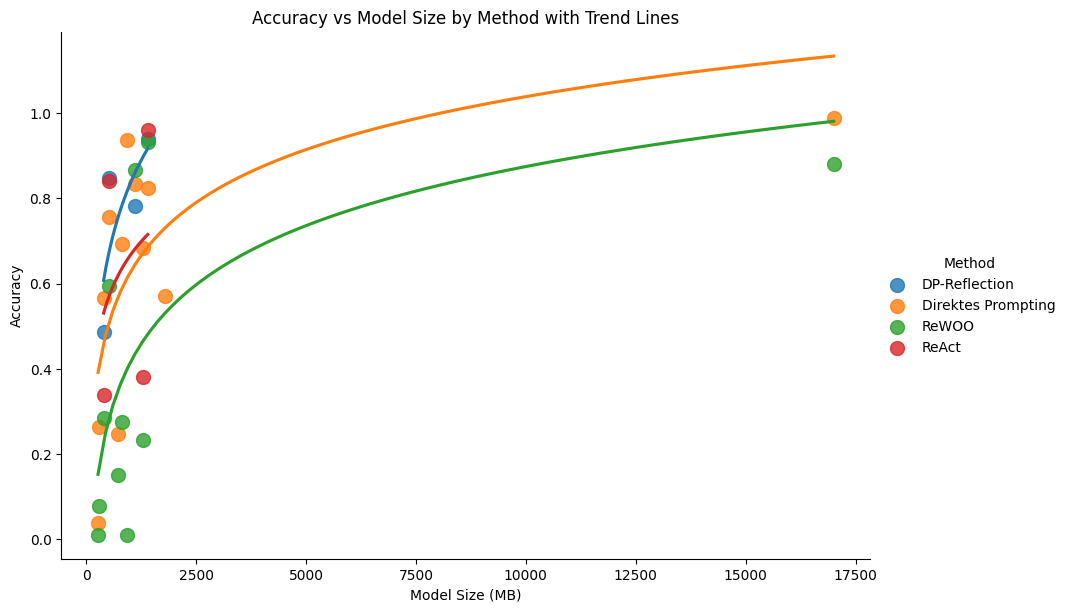

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=df_acc,
    x="model_size",
    y="is_correct",
    hue="Method",
    scatter_kws={"s": 100},
    logx=True,  # Only available in seaborn >=0.13
    aspect=1.5,
    height=6,
    markers="o",
    ci=None
)
plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size by Method with Trend Lines")
plt.show()

## Statistical Significance

### Per Method

In [53]:
df_acc = df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()

significant_results = []
n = df["ID"].nunique()
data = {}
for idx, model, method, is_correct_mean in df_acc.to_records():
    if model not in data:
        data[model] = {}
    data[model][method] = is_correct_mean

for model in data:
    items = list(data[model].items())
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            method1, score1 = items[i]
            method2, score2 = items[j]
            if method1 == method2:
                continue
                # p1: float, n1: int, p2: float, n2: int,
            r = compare_accuracies_v3(
                p1=score1,
                n1=n,
                p2=score2,
                n2=n
            )
            if r.is_significant:
                if score1 < score2:
                    method1, score1, method2, score2 = method2, score2, method1, score1
                significant_results.append({
                    "model": model,
                    "method1": method1,
                    "score1": score1,
                    "method2": method2,
                    "score2": score2,
                    "is_significant": r.is_significant,
                    "p-score": r.p_value
                })
                      
significant_results_df = pd.DataFrame.from_records(significant_results)
significant_results_df["Model_Group"] = significant_results_df["model"].apply(lambda x: model_group[x])
significant_results_df

,model,method1,score1,method2,score2,is_significant,p-score,Model_Group
0,deepseek-r1:1.5b,ReWOO,0.866197,DP-Reflection,0.781690,True,7.804122e-03,Large
1,gemma-3-27b-it,Direktes Prompting,0.989437,ReWOO,0.880282,True,6.488948e-08,Extra Large
2,gemma3:1b,Direktes Prompting,0.693662,ReWOO,0.274648,True,0.000000e+00,Medium
3,gemma3:270m,Direktes Prompting,0.264085,ReWOO,0.077465,True,1.060410e-09,Small
4,llama3.2:1b,Direktes Prompting,0.683099,ReAct,0.380282,True,3.219647e-14,Medium
5,llama3.2:1b,Direktes Prompting,0.683099,ReWOO,0.232394,True,0.000000e+00,Medium
6,llama3.2:1b,ReAct,0.380282,ReWOO,0.232394,True,1.074498e-04,Medium
7,qwen2-math:1.5b,Direktes Prompting,0.936620,ReWOO,0.010563,True,0.000000e+00,Large
8,qwen2.5:0.5b,DP-Reflection,0.485915,ReAct,0.338028,True,2.927957e-04,Medium
9,qwen2.5:0.5b,DP-Reflection,0.485915,ReWOO,0.285211,True,5.122810e-07,Medium


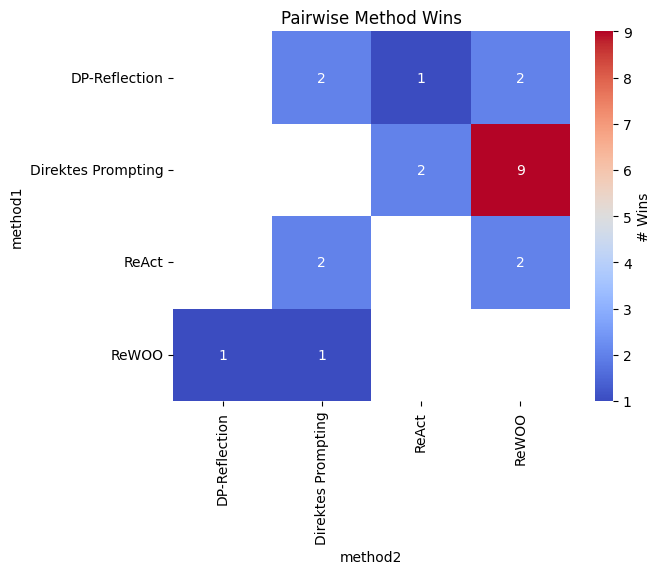

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pivot_table = significant_results_df.pivot_table(index="method1", values="is_significant", columns="method2", aggfunc="size").reset_index()
pivot_table.set_index('method1', inplace=True)
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", cbar_kws={'label':'# Wins'})
plt.title('Pairwise Method Wins')
plt.show()

In [56]:
significant_results_df.pivot_table(index="Model_Group", columns="method1", values="is_significant", aggfunc="size")

method1,DP-Reflection,Direktes Prompting,ReAct,ReWOO
Model_Group,,,,
Extra Large,NaN,1.0,NaN,NaN
Large,1.0,1.0,1.0,2.0
Medium,4.0,6.0,3.0,NaN
Small,NaN,3.0,NaN,NaN


In [66]:
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])
f = df_acc.pivot_table(index="Model_Group", columns="Method", values="is_correct", aggfunc="mean")
f.to_excel("ModelGroupSVAMP.xlsx")
f

Method,DP-Reflection,Direktes Prompting,ReAct,ReWOO
Model_Group,,,,
Extra Large,NaN,0.989437,NaN,0.880282
Large,0.860915,0.742958,0.961268,0.899648
Large (specialized),NaN,0.93662,NaN,0.010563
Medium,0.667254,0.675176,0.519953,0.346831
Small,NaN,0.183099,NaN,0.079812


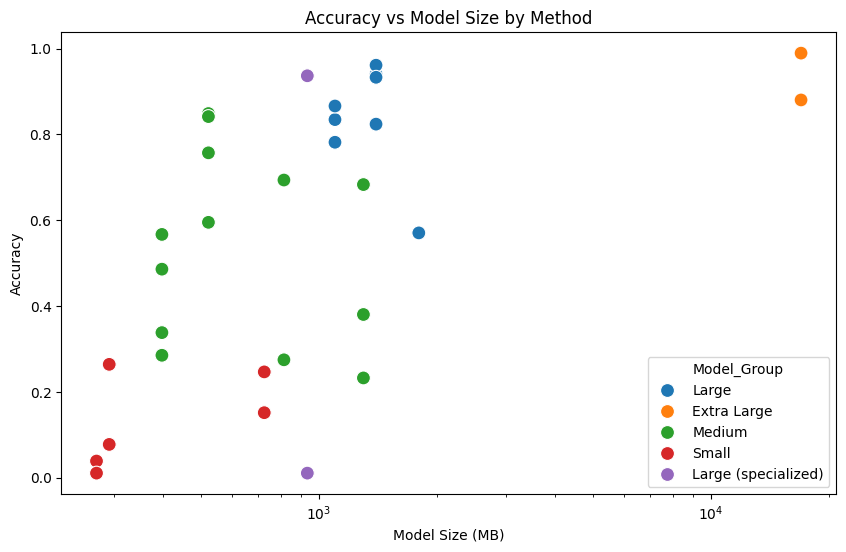

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df_acc =  df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()

df_acc["model_size"] = df_acc["Model"].apply(lambda x: models_info[x][0])
df_acc["quantization"] = df_acc["Model"].apply(lambda x: models_info[x][1])
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_acc,
    x="model_size",
    y="is_correct",
    hue="Model_Group",
    palette="tab10",
    s=100
)
plt.xlabel("Model Size (MB)")
plt.xscale("log")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size by Method")
plt.show()

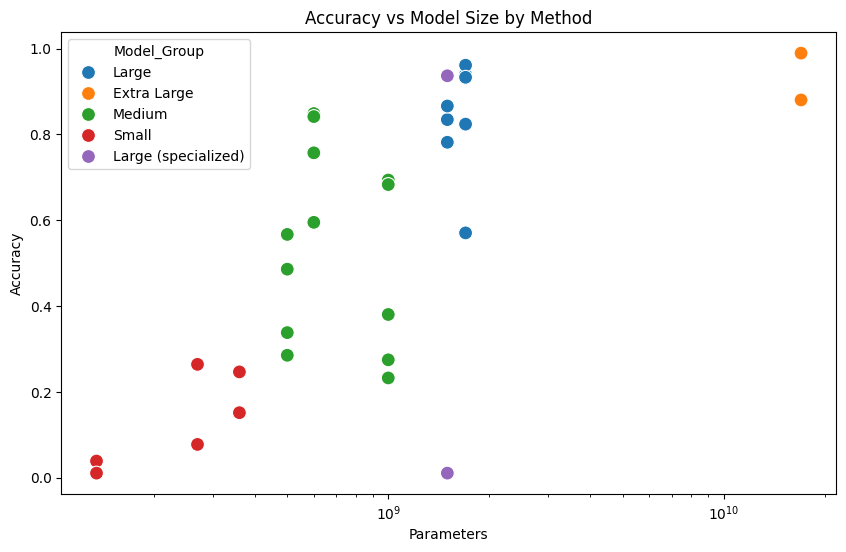

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df_acc =  df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()

df_acc["model_size"] = df_acc["Model"].apply(lambda x: models_info[x][0])
df_acc["quantization"] = df_acc["Model"].apply(lambda x: models_info[x][1])
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])
df_acc["Parameters"] = df_acc["Model"].apply(lambda x: models_info[x][2])
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_acc,
    x="Parameters",
    y="is_correct",
    hue="Model_Group",
    palette="tab10",
    s=100
)
plt.xlabel("Parameters")
plt.xscale("log")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size by Method")
plt.show()

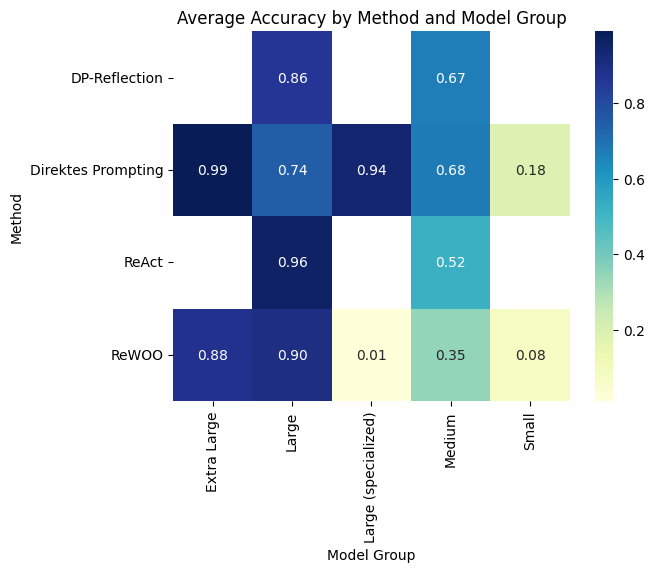

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df_acc = df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()

df_acc["model_size"] = df_acc["Model"].apply(lambda x: models_info[x][0])
df_acc["quantization"] = df_acc["Model"].apply(lambda x: model_group[x])
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])
df_acc["Parameters"] = df_acc["Model"].apply(lambda x: models_info[x][2])

heatmap_data = df_acc.pivot_table(
    index="Method",
    columns="Model_Group",
    values="is_correct",
    aggfunc="mean"
)
heatmap_data = heatmap_data.astype(float)
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Accuracy by Method and Model Group")
plt.ylabel("Method")
plt.xlabel("Model Group")
plt.show()

## Agentizität

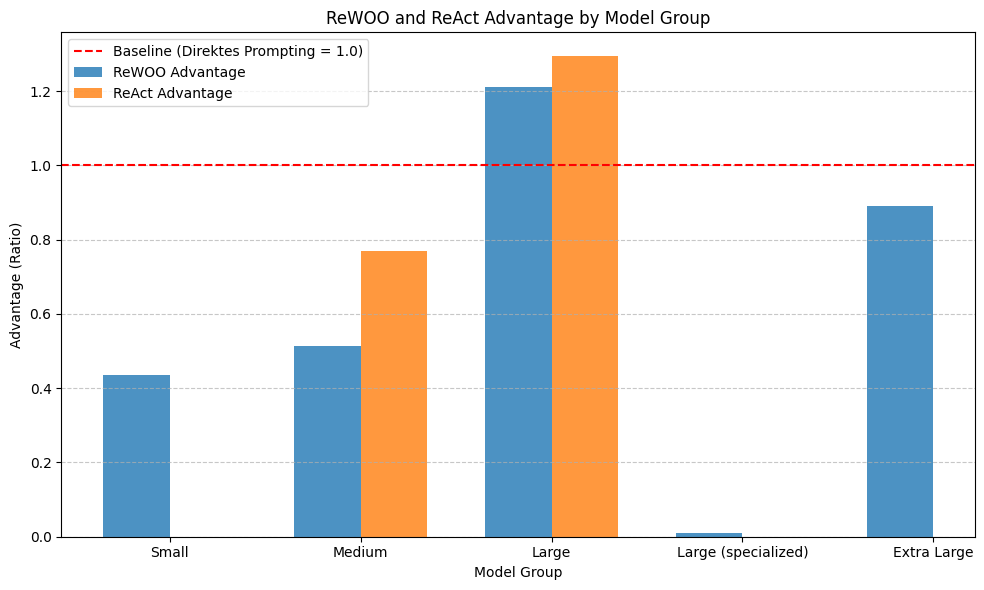

In [26]:
df_acc = df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])
f = df_acc.pivot_table(index="Model_Group", columns="Method", values="is_correct", aggfunc="mean")

f["ReWOO-Advantage"] = f["ReWOO"] / f["Direktes Prompting"]
f["ReAct-Advantage"] = f["ReAct"] / f["Direktes Prompting"]

import matplotlib.pyplot as plt
import pandas as pd

# Define the order for Model_Group
model_group_order = ["Small", "Medium", "Large", "Large (specialized)", "Extra Large"]

# Ensure Model_Group is ordered
f = f.reset_index()
f["Model_Group"] = pd.Categorical(f["Model_Group"], categories=model_group_order, ordered=True)

# Sort by Model_Group
f = f.sort_values("Model_Group")


# Plot the bar chart
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = range(len(f["Model_Group"]))

plt.bar(x, f["ReWOO-Advantage"], width=bar_width, label="ReWOO Advantage", alpha=0.8)
plt.bar([i + bar_width for i in x], f["ReAct-Advantage"], width=bar_width, label="ReAct Advantage", alpha=0.8)
plt.axhline(y=1.0, color="red", linestyle="--", linewidth=1.5, label="Baseline (Direktes Prompting = 1.0)")

# Add labels and title
plt.xticks([i + bar_width / 2 for i in x], f["Model_Group"])
plt.xlabel("Model Group")
plt.ylabel("Advantage (Ratio)")
plt.title("ReWOO and ReAct Advantage by Model Group")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\patri\AppData\Local\Temp\ipykernel_23996\1143386733.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_acc = df_acc.fillna(0)


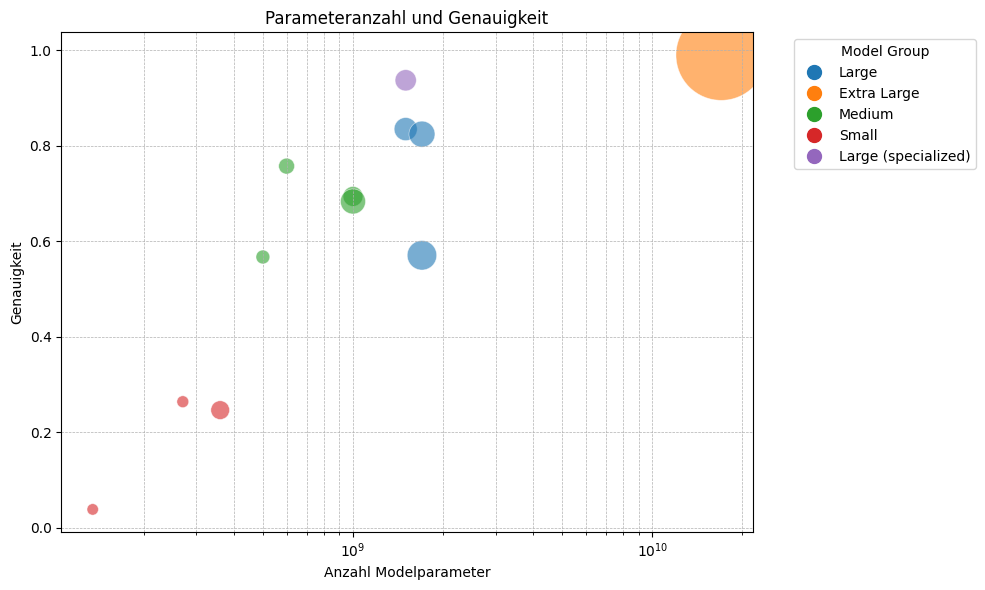

In [63]:
df_acc = df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index()
df_acc = df_acc[df_acc["Method"] == "Direktes Prompting"]
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])

df_acc["model_size"] = df_acc["Model"].apply(lambda x: models_info[x][0])
df_acc["quantization"] = df_acc["Model"].apply(lambda x: model_group[x])
df_acc["Model_Group"] = df_acc["Model"].apply(lambda x: model_group[x])
df_acc["Parameters"] = df_acc["Model"].apply(lambda x: models_info[x][2])

df_acc = df_acc.fillna(0)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Map Model_Group to colors
unique_groups = df_acc["Model_Group"].unique()
color_palette = sns.color_palette("tab10", len(unique_groups))
group_color_map = {group: color for group, color in zip(unique_groups, color_palette)}
colors = df_acc["Model_Group"].map(group_color_map)

# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=df_acc["Parameters"],
    y=df_acc["is_correct"],
    s=df_acc["model_size"]/4,  # Scale accuracy to control bubble size
    alpha=0.6,
    c=colors,
    edgecolors="w",
    linewidth=0.5,
    # s=100
)

# Add a legend for Model_Group
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10) for color in color_palette]
plt.legend(handles, unique_groups, title="Model Group", bbox_to_anchor=(1.05, 1), loc="upper left")

# Add labels and title
plt.xscale("log")
plt.xlabel("Anzahl Modelparameter")
plt.ylabel("Genauigkeit")
plt.title("Parameteranzahl und Genauigkeit")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Error Analysis

Overview

In [10]:
df_err = df.groupby(["Model", "Method", "Error Type", "Error Class"]).agg({
    "ID": "count",
}).pivot_table(
    index=["Model", "Method"],
    columns=["Error Type", "Error Class"],
    values="ID",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type              Model              Method   Execution Error  \
Error Class                                       Calculation Error   
0            deepseek-r1_1.5b  Direktes Prompting               4.0   
1            deepseek-r1_1.5b               ReWOO               1.0   
2              gemma-3-27b-it  Direktes Prompting               0.0   
3              gemma-3-27b-it               ReWOO               0.0   
4                   gemma3_1b  Direktes Prompting               2.0   
5                   gemma3_1b               ReWOO               0.0   
6                 llama3.2_1b  Direktes Prompting              11.0   
7                 llama3.2_1b               ReAct               1.0   
8                 llama3.2_1b               ReWOO               0.0   
9             qwen2-math_1.5b  Direktes Prompting               2.0   
10            qwen2-math_1.5b               ReWOO               0.0   
11               qwen2.5_0.5b  Direktes Prompting               9.0   
12               qwen2.5_0.5b               ReAct               1.0   
13               qwen2.5_0.5b               ReWOO               0.0   
14                 qwen3_0.6b  Direktes Prompting               2.0   
15                 qwen3_0.6b               ReAct               1.0   
16                 qwen3_0.6b               ReWOO               0.0   
17                 qwen3_1.7b  Direktes Prompting               0.0   
18                 qwen3_1.7b               ReAct               0.0   
19                 qwen3_1.7b               ReWOO               0.0   
20               smollm2_1.7b  Direktes Prompting              10.0   
21               smollm2_360m               ReWOO               0.0   

Error Type                                                        \
Error Class Declines to Answer  Loop Overthinking Too Few Tokens   
0                          0.0   3.0          0.0            0.0   
1                          0.0   0.0          0.0            0.0   
2                          0.0   0.0          1.0            0.0   
3                          0.0   1.0          0.0            0.0   
4                          0.0  53.0          6.0            0.0   
5                          0.0   2.0          0.0            0.0   
6                          0.0   0.0          0.0            0.0   
7                          0.0   0.0          0.0            0.0   
8                          8.0   0.0          0.0            0.0   
9                          0.0   0.0          0.0            0.0   
10                         0.0   0.0          0.0            0.0   
11                         0.0   0.0          0.0            0.0   
12                         0.0   1.0          1.0            0.0   
13                         0.0   0.0          0.0            0.0   
14                         0.0   0.0         53.0            1.0   
15                         0.0   0.0          9.0            0.0   
16                         0.0  20.0         18.0            0.0   
17                         0.0   5.0         32.0           13.0   
18                         0.0   0.0          4.0            0.0   
19                         0.0   2.0          2.0            0.0   
20                         1.0   1.0          0.0            0.0   
21                         0.0   1.0          0.0            0.0   

Error Type                       Structural Error                    \
Error Class Wrong Reasoning Equation Format Error Plan Format Error   
0                      40.0                   0.0               0.0   
1                      13.0                   2.0              14.0   
2                       2.0                   0.0               0.0   
3                      32.0                   0.0               1.0   
4                      26.0                   0.0               0.0   
5                     172.0                   0.0               2.0   
6                      79.0                   0.0               0.0   
7                     1

In [13]:
error_classes = [s for s in df["Error Class"].unique() if isinstance(s, str)]

print(f"Length of error classes: {len(error_classes)}")

Length of error classes: 11


In [21]:
e = error_classes[1]

ltx_all = ""


df_err = df.groupby(["Model", "Method", "Error Class"]).agg({
    "ID": "count",
}).reset_index()

for e in error_classes:
    df_tmp = df_err[df_err["Error Class"] == e]
    ltx = (
        df_tmp.pivot_table(
            index=["Model"],
            columns=["Method"],
            values="ID",
            fill_value=pd.NA
        )              # convert to int type
        .reset_index()
        .to_latex(index=False, 
                caption=f'Fehleranalyse von {e} für SVAMP nach Modell und Methode',
                label=f'tab:error_analysis_{e.replace(" ", "_").lower()}',
                escape=False)
    )
    ltx_all += ltx + "\n\n"

print(ltx_all)

\begin{table}
\caption{Fehleranalyse von Wrong Reasoning für SVAMP nach Modell und Methode}
\label{tab:error_analysis_wrong_reasoning}
\begin{tabular}{lrrr}
\toprule
Model & Direktes Prompting & ReAct & ReWOO \\
\midrule
deepseek-r1_1.5b & 40.000000 & NaN & 13.000000 \\
gemma-3-27b-it & 2.000000 & NaN & 32.000000 \\
gemma3_1b & 26.000000 & NaN & 172.000000 \\
llama3.2_1b & 79.000000 & 163.000000 & 118.000000 \\
qwen2-math_1.5b & 16.000000 & NaN & NaN \\
qwen2.5_0.5b & 114.000000 & 158.000000 & 168.000000 \\
qwen3_0.6b & 13.000000 & 35.000000 & 39.000000 \\
qwen3_1.7b & NaN & 7.000000 & 13.000000 \\
smollm2_1.7b & 107.000000 & NaN & NaN \\
smollm2_360m & NaN & NaN & 133.000000 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Fehleranalyse von Overthinking für SVAMP nach Modell und Methode}
\label{tab:error_analysis_overthinking}
\begin{tabular}{lrrr}
\toprule
Model & Direktes Prompting & ReAct & ReWOO \\
\midrule
gemma-3-27b-it & 1.000000 & NaN & NaN \\
gemma3_1b & 6.00

In [ ]:
e = error_classes[0]

df_err = df.groupby(["Model", "Method", "Error Class"]).agg({
    "ID": "count",
}).pivot_table(
    index=["Model"],
    columns=["Method"],
    values="ID",
    fill_value=pd.NA
).reset_index()

df_err.head(50)

Method,Model,Direct Prompting,ReAct,ReWOO
0,google/gemma-3-27b-it,1.500000,NaN,11.333333
1,ollama/deepseek-r1_1.5b,15.666667,NaN,5.428571
2,ollama/gemma3_1b,21.750000,NaN,41.200000
3,ollama/llama3.2_1b,45.000000,58.666667,43.600000
4,ollama/qwen2-math_1.5b,9.000000,NaN,281.000000
5,ollama/qwen2.5_0.5b,61.500000,37.600000,50.750000
6,ollama/qwen3_0.6b,17.250000,15.000000,19.833333
7,ollama/qwen3_1.7b,16.666667,5.500000,4.750000
8,ollama/smollm2_1.7b,29.750000,NaN,NaN
9,ollama/smollm2_360m,NaN,NaN,48.200000


## Statistical Significance

In [64]:
significant_results = []
n = df["ID"].nunique()
data = {}
headers = df_err.columns.tolist()[:-1]

for item in df_err.to_records():
    model = item[1]
    method = item[2]

    if model not in data:
        data[model] = []
    item = list(item)[1:-1]
    data[model].append(item)

for model in data:
    items = data[model]
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            for k in range(3, len(headers)):
                method1 = items[i][1]
                method2 = items[j][1]
                score1 = items[i][k] / n
                score2 = items[j][k] / n
                if method1 == method2:
                    continue
                r = compare_accuracies_v3(
                    p1=score1,
                    n1=n,
                    p2=score2,
                    n2=n
                )
                # print(f"Comparing {method1} vs {method2} for {headers[k]} in {model}: {score1} vs {score2} => is_significant: {r.is_significant}")
                if r.is_significant:
                    if score1 < score2:
                        method1, score1, method2, score2 = method2, score2, method1, score1
                    significant_results.append({
                        "model": model,
                        "Error Class": headers[k],
                        "method1": method1,
                        "score1": score1 * n,
                        "method2": method2,
                        "score2": score2 * n,
                        "is_significant": r.is_significant,
                    })
                    
                
                
significant_results_df = pd.DataFrame.from_records(significant_results)
# Drop all rows where score1 or score2 is 0
significant_results_df = significant_results_df[(significant_results_df["score1"] > 0) & (significant_results_df["score2"] > 0)]

significant_results_df

,model,Error Class,method1,score1,method2,score2,is_significant
0,google/gemma-3-27b-it,"(Execution Error, Wrong Reasoning)",ReWOO,32.0,Direct Prompting,2.0,True
1,ollama/deepseek-r1_1.5b,"(Execution Error, Wrong Reasoning)",Direct Prompting,40.0,ReWOO,13.0,True
4,ollama/gemma3_1b,"(Execution Error, Loop)",Direct Prompting,53.0,ReWOO,2.0,True
6,ollama/gemma3_1b,"(Execution Error, Wrong Reasoning)",ReWOO,172.0,Direct Prompting,26.0,True
9,ollama/llama3.2_1b,"(Execution Error, Wrong Reasoning)",ReAct,163.0,Direct Prompting,79.0,True
12,ollama/llama3.2_1b,"(Execution Error, Wrong Reasoning)",ReWOO,118.0,Direct Prompting,79.0,True
17,ollama/llama3.2_1b,"(Execution Error, Wrong Reasoning)",ReAct,163.0,ReWOO,118.0,True
22,ollama/qwen2.5_0.5b,"(Execution Error, Wrong Reasoning)",ReAct,158.0,Direct Prompting,114.0,True
24,ollama/qwen2.5_0.5b,"(Execution Error, Wrong Reasoning)",ReWOO,168.0,Direct Prompting,114.0,True
28,ollama/qwen2.5_0.5b,"(Tool Error, Tool Error)",ReAct,27.0,ReWOO,6.0,True


Interpretation: 

- **Gemma3 27B**: 
    - Wrong Reasoning: 
        - ReWOO > DP
- **Deepseek**: 
    - Wrong Reasoning: 
        - DP > ReWOO
- **Gemma**:
    - Error Loops: DP > ReWOO
    - Wrong Reasoning: ReWOO > DP
- **Llama**:
    - Wrong Reasoning: 
        - ReWOO > DP
        - ReAct > DP
        - ReWOO > ReAct
- **Qwen 2.5 0.5B**:
    - Wrong Reasoning:
        - ReAct > DP
        - ReWOO > DP
    - Tool Errors:
        - ReAct > ReWOO
- **Qwen3 0.6B**:
    - Overthinking:
        - ReAct > ReWOO
        - DP > ReWOO
    - Wrong Reasoning:
        - ReAct > DP
        - ReWOO > DP
- **Qwen3 1.7B**:
    - Overthinking:
        - DP > ReAct
        - DP > ReWOO

In [65]:
df_err["Model-Method"] = df_err["Model"] + " - " + df_err["Method"]

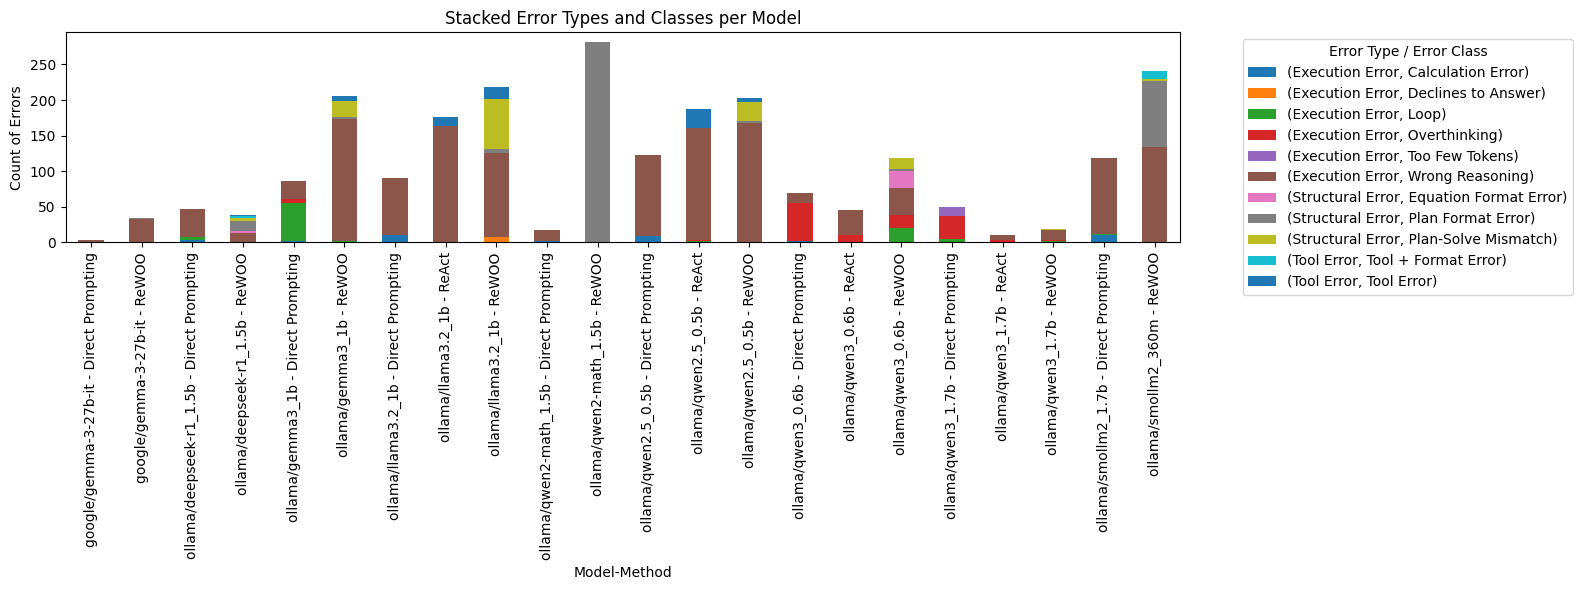

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model-Method")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Per Operation Type

In [22]:
# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Type'] not in question_type_mapping:
                question_type_mapping[row['Type']] = 0
            question_type_mapping[row['Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

# Convert to a DataFrame for better visualization
question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

,Question Type,Count
0,Subtraction,153
3,Addition,55
1,Common-Division,44
2,Multiplication,32


In [23]:
qtypes_df = df.groupby(["Model", "Method", "Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100

qtypes_df

,Model,Method,Type,is_correct,Total_Questions,Correct_Score
0,deepseek-r1_1.5b,Direktes Prompting,Addition,50,55,90.909091
1,deepseek-r1_1.5b,Direktes Prompting,Common-Division,35,44,79.545455
2,deepseek-r1_1.5b,Direktes Prompting,Multiplication,25,32,78.125
3,deepseek-r1_1.5b,Direktes Prompting,Subtraction,127,153,83.006536
4,deepseek-r1_1.5b,ReWOO,Addition,50,55,90.909091
...,...,...,...,...,...,...
83,smollm2_1.7b,Direktes Prompting,Subtraction,85,153,55.555556
84,smollm2_360m,ReWOO,Addition,6,55,10.909091
85,smollm2_360m,ReWOO,Common-Division,6,44,13.636364
86,smollm2_360m,ReWOO,Multiplication,3,32,9.375


In [24]:
qtypes_df.to_records()

rec.array([( 0, 'deepseek-r1_1.5b', 'Direktes Prompting', 'Addition', 50,  55, 90.9090909090909),
           ( 1, 'deepseek-r1_1.5b', 'Direktes Prompting', 'Common-Division', 35,  44, 79.54545454545455),
           ( 2, 'deepseek-r1_1.5b', 'Direktes Prompting', 'Multiplication', 25,  32, 78.125),
           ( 3, 'deepseek-r1_1.5b', 'Direktes Prompting', 'Subtraction', 127, 153, 83.00653594771242),
           ( 4, 'deepseek-r1_1.5b', 'ReWOO', 'Addition', 50,  55, 90.9090909090909),
           ( 5, 'deepseek-r1_1.5b', 'ReWOO', 'Common-Division', 38,  44, 86.36363636363636),
           ( 6, 'deepseek-r1_1.5b', 'ReWOO', 'Multiplication', 26,  32, 81.25),
           ( 7, 'deepseek-r1_1.5b', 'ReWOO', 'Subtraction', 132, 153, 86.27450980392157),
           ( 8, 'gemma-3-27b-it', 'Direktes Prompting', 'Addition', 54,  55, 98.18181818181819),
           ( 9, 'gemma-3-27b-it', 'Direktes Prompting', 'Common-Division', 43,  44, 97.72727272727273),
           (10, 'gemma-3-27b-it', 'Direktes Prompt

In [25]:
significant_results = []
n = df["ID"].nunique()
data = {}
headers = qtypes_df.columns.tolist()[:-1]

for item in qtypes_df.to_records():
    model = item[1]
    method = item[2]
    operation = item[3]
    is_correct = item[4]
    count = item[5]
    correct_score = item[6]

    if model not in data:
        data[model] = {}
    if operation not in data[model]:
        data[model][operation] = []
    item = (model, method, operation, is_correct, count, correct_score)
    data[model][operation].append(item)

for model in data:
    operations = list(data[model].keys())
    for operation in operations:
        items = data[model][operation]
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                method1 = items[i][1]
                method2 = items[j][1]
                score1 = items[i][5]/100
                score2 = items[j][5]/100
                n1 = items[i][4]
                n2 = items[j][4]

                if method1 == method2:
                    continue
                r = compare_accuracies_v3(
                    p1=score1,
                    n1=n1,
                    p2=score2,
                    n2=n2
                )
                # print(f"Comparing {method1} vs {method2} for {headers[k]} in {model}: {score1} vs {score2} => is_significant: {r.is_significant}")
                if r.is_significant:
                    if score1 < score2:
                        method1, score1, method2, score2 = method2, score2, method1, score1
                    significant_results.append({
                        "model": model,
                        "Operation": operation,
                        "method1": method1,
                        "score1": score1,
                        "method2": method2,
                        "score2": score2,
                        "is_significant": r.is_significant,
                    })
                        
                
                
significant_results_df = pd.DataFrame.from_records(significant_results)
# Drop all rows where score1 or score2 is 0
significant_results_df = significant_results_df[(significant_results_df["score1"] > 0) & (significant_results_df["score2"] > 0)]

significant_results_df

,model,Operation,method1,score1,method2,score2,is_significant
0,gemma-3-27b-it,Addition,Direktes Prompting,0.981818,ReWOO,0.872727,True
1,gemma-3-27b-it,Common-Division,Direktes Prompting,0.977273,ReWOO,0.818182,True
2,gemma-3-27b-it,Subtraction,Direktes Prompting,0.993464,ReWOO,0.888889,True
3,gemma3_1b,Addition,Direktes Prompting,0.636364,ReWOO,0.218182,True
4,gemma3_1b,Common-Division,Direktes Prompting,0.750000,ReWOO,0.318182,True
5,gemma3_1b,Multiplication,Direktes Prompting,0.687500,ReWOO,0.187500,True
6,gemma3_1b,Subtraction,Direktes Prompting,0.699346,ReWOO,0.300654,True
7,llama3.2_1b,Addition,Direktes Prompting,0.636364,ReAct,0.436364,True
8,llama3.2_1b,Addition,Direktes Prompting,0.636364,ReWOO,0.181818,True
9,llama3.2_1b,Addition,ReAct,0.436364,ReWOO,0.181818,True


# Question Type

In [86]:
# Different question types
def classify_question_type(question):
    if "how many more" in question.lower():
        return "How Many More"
    elif "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "how big" in question.lower():
        return "How Big"
    elif "how long" in question.lower():
        return "How Long"
    elif "what is" in question.lower():
        return "What is"
    elif "how deep" in question.lower():
        return "How Deep"
    elif "how far" in question.lower():
        return "How Far"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['Question-only'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Many More,75
2,How Much,33
3,How Big,3
4,What is,2
5,How Long,2
7,How Far,2
6,How Deep,1


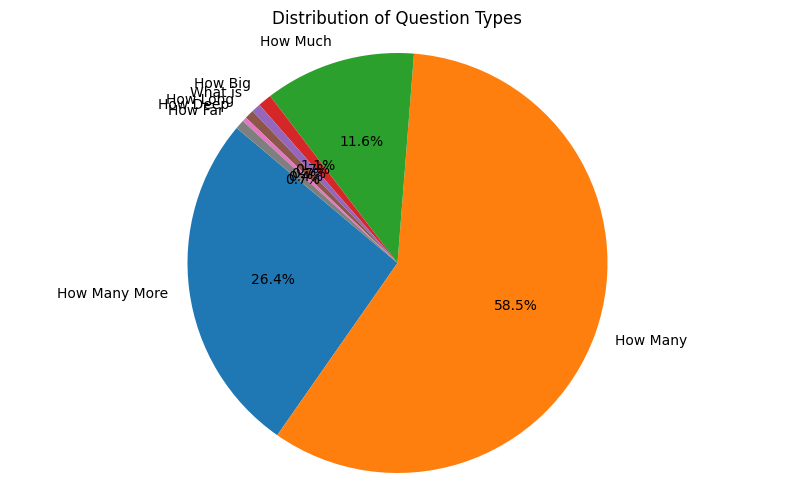

In [88]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [87]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_5429/3781238049.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)


Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_1.7b,ollama/smollm2_360m
Question_Type,,,,,,,,,,
How Big,200.000000,166.666667,133.333333,133.333333,100.000000,233.333333,200.000000,266.666667,66.666667,0.000000
How Deep,200.000000,200.000000,100.000000,100.000000,100.000000,100.000000,300.000000,300.000000,100.000000,0.000000
How Far,200.000000,200.000000,100.000000,100.000000,100.000000,100.000000,300.000000,250.000000,0.000000,0.000000
How Long,200.000000,200.000000,100.000000,150.000000,100.000000,150.000000,250.000000,300.000000,50.000000,0.000000
How Many,186.746988,175.903614,95.783133,135.542169,96.385542,131.927711,221.686747,271.084337,61.445783,15.060241
How Many More,184.000000,161.333333,93.333333,116.000000,93.333333,82.666667,217.333333,280.000000,52.000000,20.000000
How Much,190.909091,154.545455,103.030303,130.303030,87.878788,118.181818,203.030303,254.545455,54.545455,6.060606
What is,200.000000,200.000000,150.000000,150.000000,100.000000,250.000000,250.000000,300.000000,100.000000,50.000000


# Token Usage

In [8]:
mean_token_usage = df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
mean_token_usage

mean_correct_answers  mean_input_tokens  \
Model            Method                                                       
deepseek-r1_1.5b DP-Reflection                   0.78169        2331.922535   
                 Direktes Prompting             0.834507          44.584507   
                 ReWOO                          0.866197         692.024648   
gemma-3-27b-it   Direktes Prompting             0.989437                NaN   
                 ReWOO                          0.880282         742.306338   
gemma3_1b        Direktes Prompting             0.693662          49.880282   
                 ReWOO                          0.274648         737.940141   
llama3.2_1b      Direktes Prompting             0.683099          64.119718   
                 ReAct                          0.380282         622.605634   
                 ReWOO                          0.232394         694.014085   
qwen2-math_1.5b  Direktes Prompting              0.93662          47.584507   
                 ReWOO                          0.010563         515.042254   
qwen2.5_0.5b     DP-Reflection                  0.485915        1827.404930   
                 Direktes Prompting             0.566901          70.584507   
                 ReAct                          0.338028         988.922535   
                 ReWOO                          0.285211         769.735915   
qwen3_0.6b       DP-Reflection                  0.848592        3810.348592   
                 Direktes Prompting             0.757042          49.584507   
                 ReAct                          0.841549         527.172535   
                 ReWOO                           0.59507         679.469965   
qwen3_1.7b       DP-Reflection                  0.940141        4412.908451   
                 Direktes Prompting             0.823944          49.584507   
                 ReAct                          0.961268        1041.792254   
                 ReWOO                          0.933099         688.731449   
smollm2_1.7b     Direktes Prompting             0.580986          70.577465   
smollm2_360m     Direktes Prompting             0.246479          71.577465   
                 ReWOO                          0.151408         742.686620   

                                     mean_output_tokens  mean_total_tokens  
Model            Method                                                     
deepseek-r1_1.5b DP-Reflection              1477.911972        3809.834507  
                 Direktes Prompting          325.528169         370.112676  
                 ReWOO                       984.982394        1677.007042  
gemma-3-27b-it   Direktes Prompting                 NaN                NaN  
                 ReWOO                         0.000000         742.306338  
gemma3_1b        Direktes Prompting          697.802817         747.683099  
                 ReWOO                       111.070423         849.010563  
llama3.2_1b      Direktes Prompting           98.278169         162.397887  
                 ReAct                        60.985915         683.591549  
                 ReWOO                        50.471831         744.485915  
qwen2-math_1.5b  Direktes Prompting          203.021127         250.605634  
                 ReWOO                       247.031690         762.073944  
qwen2.5_0.5b     DP-Reflection               780.267606        2607.672535  
                 Direktes Prompting          212.253521         282.838028  
                 ReAct                        84.246479        1073.169014  
                 ReWOO                       106.760563         876.496479  
qwen3_0.6b       DP-Reflection              2371.623239        6181.971831  
                 Direktes Prompting         1064.556338        1114.140845  
                 ReAct                       455.809859         982.982394  
                 ReWOO                      1169.286219        1848.756184  
qwen3_1.7b       DP-Reflection              2673.7

In [32]:
ltx = mean_token_usage.reset_index().to_latex(
    index=False,
    caption='Durchschnittliche Token-Nutzung und korrekte Antworten für SVAMP nach Modell und Methode',
    label='tab:mean_token_usage_svamp',
)
print(ltx)

\begin{table}
\caption{Durchschnittliche Token-Nutzung und korrekte Antworten für SVAMP nach Modell und Methode}
\label{tab:mean_token_usage_svamp}
\begin{tabular}{lllrrr}
\toprule
Model & Method & mean_correct_answers & mean_input_tokens & mean_output_tokens & mean_total_tokens \\
\midrule
deepseek-r1_1.5b & Direktes Prompting & 0.834507 & 44.584507 & 325.528169 & 370.112676 \\
deepseek-r1_1.5b & ReWOO & 0.866197 & 692.024648 & 984.982394 & 1677.007042 \\
gemma-3-27b-it & Direktes Prompting & 0.989437 & NaN & NaN & NaN \\
gemma-3-27b-it & ReWOO & 0.880282 & 742.306338 & 0.000000 & 742.306338 \\
gemma3_1b & Direktes Prompting & 0.693662 & 49.880282 & 697.802817 & 747.683099 \\
gemma3_1b & ReWOO & 0.274648 & 737.940141 & 111.070423 & 849.010563 \\
llama3.2_1b & Direktes Prompting & 0.683099 & 64.119718 & 98.278169 & 162.397887 \\
llama3.2_1b & ReAct & 0.380282 & 622.605634 & 60.985915 & 683.591549 \\
llama3.2_1b & ReWOO & 0.232394 & 694.014085 & 50.471831 & 744.485915 \\
qwen2-math_1.5b

In [ ]:
ltx = df[df["is_correct"] == True].groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
).to_latex(
    index=False,
    caption='Durchschnittliche Token-Nutzung und korrekte Antworten für SVAMP nach Modell und Methode',
    label='tab:mean_token_usage_svamp',
)
print(ltx)

'\\begin{table}\n\\caption{Durchschnittliche Token-Nutzung und korrekte Antworten für SVAMP nach Modell und Methode}\n\\label{tab:mean_token_usage_svamp}\n\\begin{tabular}{lrrr}\n\\toprule\nmean_correct_answers & mean_input_tokens & mean_output_tokens & mean_total_tokens \\\\\n\\midrule\n1.000000 & 43.324895 & 286.548523 & 329.873418 \\\\\n1.000000 & 697.410569 & 892.804878 & 1590.215447 \\\\\n1.000000 & NaN & NaN & NaN \\\\\n1.000000 & 726.332000 & 0.000000 & 726.332000 \\\\\n1.000000 & 47.868020 & 323.928934 & 371.796954 \\\\\n1.000000 & 725.141026 & 86.538462 & 811.679487 \\\\\n1.000000 & 62.432990 & 81.932990 & 144.365979 \\\\\n1.000000 & 622.231481 & 67.185185 & 689.416667 \\\\\n1.000000 & 695.787879 & 46.878788 & 742.666667 \\\\\n1.000000 & 47.116541 & 191.751880 & 238.868421 \\\\\n1.000000 & 653.000000 & 389.000000 & 1042.000000 \\\\\n1.000000 & 67.906832 & 184.031056 & 251.937888 \\\\\n1.000000 & 936.416667 & 66.989583 & 1003.406250 \\\\\n1.000000 & 751.111111 & 95.111111 & 846

In [7]:
df[df["is_correct"] == False].groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)

mean_correct_answers  mean_input_tokens  \
Model            Method                                                       
deepseek-r1_1.5b DP-Reflection                       0.0        2751.354839   
                 Direktes Prompting                  0.0          50.936170   
                 ReWOO                               0.0         657.157895   
gemma-3-27b-it   Direktes Prompting                  0.0                NaN   
                 ReWOO                               0.0         859.764706   
gemma3_1b        Direktes Prompting                  0.0          54.436782   
                 ReWOO                               0.0         742.786408   
llama3.2_1b      Direktes Prompting                  0.0          67.755556   
                 ReAct                               0.0         622.835227   
                 ReWOO                               0.0         693.477064   
qwen2-math_1.5b  Direktes Prompting                  0.0          54.500000   
                 ReWOO                               0.0         513.569395   
qwen2.5_0.5b     DP-Reflection                       0.0        1928.904110   
                 Direktes Prompting                  0.0          74.089431   
                 ReAct                               0.0        1015.734043   
                 ReWOO                               0.0         777.167488   
qwen3_0.6b       DP-Reflection                       0.0        5708.139535   
                 Direktes Prompting                  0.0          55.000000   
                 ReAct                               0.0         580.600000   
                 ReWOO                               0.0         613.745614   
qwen3_1.7b       DP-Reflection                       0.0        6033.882353   
                 Direktes Prompting                  0.0          56.360000   
                 ReAct                               0.0        1072.454545   
                 ReWOO                               0.0         659.315789   
smollm2_1.7b     Direktes Prompting                  0.0          74.159664   
smollm2_360m     Direktes Prompting                  0.0          71.733645   
                 ReWOO                               0.0         730.282158   

                                     mean_output_tokens  mean_total_tokens  
Model            Method                                                     
deepseek-r1_1.5b DP-Reflection              1961.967742        4713.322581  
                 Direktes Prompting          522.085106         573.021277  
                 ReWOO                      1581.710526        2238.868421  
gemma-3-27b-it   Direktes Prompting                 NaN                NaN  
                 ReWOO                         0.000000         859.764706  
gemma3_1b        Direktes Prompting         1544.390805        1598.827586  
                 ReWOO                       120.359223         863.145631  
llama3.2_1b      Direktes Prompting          133.511111         201.266667  
                 ReAct                        57.181818         680.017045  
                 ReWOO                        51.559633         745.036697  
qwen2-math_1.5b  Direktes Prompting          369.555556         424.055556  
                 ReWOO                       245.516014         759.085409  
qwen2.5_0.5b     DP-Reflection               867.835616        2796.739726  
                 Direktes Prompting          249.195122         323.284553  
                 ReAct                        93.058511        1108.792553  
                 ReWOO                       111.408867         888.576355  
qwen3_0.6b       DP-Reflection              4137.116279        9845.255814  
                 Direktes Prompting         1848.072464        1903.072464  
                 ReAct                       905.688889        1486.288889  
                 ReWOO                      1443.052632        2056.798246  
qwen3_1.7b       DP-Reflection              4365.3

In [4]:
len(df["Model"].unique())


10

## Statistical Significance

In [46]:
import pandas as pd
n = df["ID"].nunique()
significant_results = []
for idx, row in df_acc.iterrows():
    methods = df["Method"].unique()
    for i in range(len(methods)):
        for j in range(i + 1, len(methods)):
            method1 = methods[i]
            method2 = methods[j]
            score1 = row[method1]
            score2 = row[method2]
            result = compare_accuracies_v3(score1, n, score2, n)
            if result.is_significant:
                significant_results.append((row["Model"], row["Model"], method1, method2, score1, score2, result.p_value, result.is_significant))

significant_results_df = pd.DataFrame([
    {
        'Model': model1,
        # 'Model2': model2,
        'Method1': method1,
        'Method2': method2,
        # 'Score1': score1,
        # 'Score2': score2,
        'p_value': p_value,
        'is_significant': is_significant
    }
    for model1, model2, method1, method2, score1, score2, p_value, is_significant in significant_results
])
print(significant_results_df.to_latex(index=False))

\begin{tabular}{lllrr}
\toprule
Model & Method1 & Method2 & p_value & is_significant \\
\midrule
deepseek-r1_1.5b & DP-Reflection & ReWOO & 0.007804 & True \\
gemma-3-27b-it & Direktes Prompting & ReWOO & 0.000000 & True \\
gemma3_1b & Direktes Prompting & ReWOO & 0.000000 & True \\
llama3.2_1b & Direktes Prompting & ReAct & 0.000000 & True \\
llama3.2_1b & Direktes Prompting & ReWOO & 0.000000 & True \\
llama3.2_1b & ReAct & ReWOO & 0.000107 & True \\
qwen2-math_1.5b & Direktes Prompting & ReWOO & 0.000000 & True \\
qwen2.5_0.5b & Direktes Prompting & ReAct & 0.000000 & True \\
qwen2.5_0.5b & Direktes Prompting & ReWOO & 0.000000 & True \\
qwen2.5_0.5b & DP-Reflection & ReAct & 0.000293 & True \\
qwen2.5_0.5b & DP-Reflection & ReWOO & 0.000001 & True \\
qwen3_0.6b & Direktes Prompting & DP-Reflection & 0.005776 & True \\
qwen3_0.6b & Direktes Prompting & ReAct & 0.011460 & True \\
qwen3_0.6b & Direktes Prompting & ReWOO & 0.000028 & True \\
qwen3_0.6b & DP-Reflection & ReWOO & 0.00000

In [47]:
import pandas as pd
n = 284
significant_results = []
for idx, row in df_acc.iterrows():
    methods = df["Method"].unique()
    for i in range(len(methods)):
        for j in range(i + 1, len(methods)):
            method1 = methods[i]
            method2 = methods[j]
            score1 = row[method1]
            score2 = row[method2]
            result = compare_accuracies_v3(score1/100, n, score2/100, n)
            significant_results.append((row["Model"], row["Model"], method1, method2, score1, score2, result.p_value, result.is_significant))

significant_results_df = pd.DataFrame([
    {
        'Model': model1,
        # 'Model2': model2,
        'Method1': method1,
        'Method2': method2,
        'Score1': score1,
        'Score2': score2,
        'p_value': p_value,
        'is_significant': is_significant
    }
    for model1, model2, method1, method2, score1, score2, p_value, is_significant in significant_results
])
print(significant_results_df.to_latex(index=False))

\begin{tabular}{lllrrrr}
\toprule
Model & Method1 & Method2 & Score1 & Score2 & p_value & is_significant \\
\midrule
deepseek-r1_1.5b & Direktes Prompting & DP-Reflection & 0.834507 & 0.781690 & 0.943956 & False \\
deepseek-r1_1.5b & Direktes Prompting & ReAct & 0.834507 & NaN & 1.000000 & False \\
deepseek-r1_1.5b & Direktes Prompting & ReWOO & 0.834507 & 0.866197 & 0.967195 & False \\
deepseek-r1_1.5b & DP-Reflection & ReAct & 0.781690 & NaN & 1.000000 & False \\
deepseek-r1_1.5b & DP-Reflection & ReWOO & 0.781690 & 0.866197 & 0.911298 & False \\
deepseek-r1_1.5b & ReAct & ReWOO & NaN & 0.866197 & 1.000000 & False \\
gemma-3-27b-it & Direktes Prompting & DP-Reflection & 0.989437 & NaN & 1.000000 & False \\
gemma-3-27b-it & Direktes Prompting & ReAct & 0.989437 & NaN & 1.000000 & False \\
gemma-3-27b-it & Direktes Prompting & ReWOO & 0.989437 & 0.880282 & 0.892482 & False \\
gemma-3-27b-it & DP-Reflection & ReAct & NaN & NaN & 1.000000 & False \\
gemma-3-27b-it & DP-Reflection & ReWOO